<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões tangenciais em vigas com carregamentos transversais

### Problema 4

A viga AB é fabricada com um perfil de aço laminado HEB300 reforçado com duas barras de latão com 300 $\times$ 50 mm $^2$ ligadas ao perfil de aço com parafusos, resultando na secção transversal representada na figura. A viga suporta uma carga distribuída uniforme e os diagramas de $V_y$ e $M_z$ são também indicados na figura.

a) Sabendo que $E_\mathrm{aço}$ = 210 GPa e $E_\mathrm{latão}$ = 105 GPa, determine as tensões normais máximas que ocorrem no latão e no aço. Desenhe um diagrama mostrando a variação da tensão normal ao longo do eixo $y$.

b) Sabendo que o espaçamento entre parafusos é de 300 mm, determine o maior valor da força de corte que os parafusos suportam.

c) Calcule a tensão tangencial máxima que ocorre no perfil HEB300.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au05/P4/MSII_Au05_P4.png"
style="max-height: 100%; max-width: 100%;"/>

### Resolução

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa
# Create an empty class
class varin: pass

aco = varin()
lat = varin()
d = varin()
HEB300 = varin()

HEB300.A = 14900. # unit: mm2
HEB300.d = 300. # unit: mm - altura
HEB300.bf = 300. # unit: mm - Banzo - largura
HEB300.tf = 19. # unit: mm - Banzo - espessura
HEB300.tw = 11. # unit: mm - Alma - espessura
HEB300.Iz = 252.e6 # unit: mm4
HEB300.Iy = 85.6e6 # unit: mm4

aco.E = 210.e3 # unit MPa
lat.E = 105.e3 # unit MPa
lat.b = 300  # unit MPa
lat.t = 50  # unit MPa

d.Vmax = 400.e3 # unit: N
d.Mmax = 400 # unit: N.mm
d.paraffilas = 2
d.parafdist = 300

#### a) Sabendo que $E_\mathrm{aço}$ = 210 GPa e $E_\mathrm{latão}$ = 105 GPa, determine as tensões normais máximas que ocorrem no latão e no aço. Desenhe um diagrama mostrando a variação da tensão normal ao longo do eixo $y$.

Na presença de um problema com vigas compostas é necessário antes de mais obter uma viga transformada, homogénea equivalente.

- Razão de módulos considerando a secção transformada em aço:

\begin{equation*}
n = \frac{E_\mathrm{lat}}{E_\mathrm{aco}}
\end{equation*}

In [2]:
n = lat.E/aco.E
print(f'n = Ew/Es = {n:.1f}')

n = Ew/Es = 0.5


Mantendo a altura da viga (viga composta em altura), qual será a área da região transformada de latão em aço?

In [3]:
lat.b2a = lat.b*n
print(f'lat.b2a (largura da barra de latão transformada em aço) = {lat.b2a:.1f} [mm]')
lat.A2a = lat.b2a*lat.t
print(f'lat.A2a = {lat.A2a:.1f} [mm²]')

lat.b2a (largura da barra de latão transformada em aço) = 150.0 [mm]
lat.A2a = 7500.0 [mm²]


- Para a secção homogénea equivalente feita apenas de aço, onde está localizado o centroide da secção? E qual é o momento de inércia da secção em relação ao eixo $z$?

De acordo com a geometria da secção, o centroide é facilmente determinado como sendo o centro geométrico do perfil. O momento de inércia pode ser calculado usando operações booleanas e, eventualmente, recorrendo ao teorema dos eixos paralelos.

In [17]:
def irec(i,j): return i*j**3/12

print('HEB300 (por consulta em tabela):')
Iz1 = HEB300.Iz
print(f'Iz (HEB300) :: {Iz1:.3e} [mm⁴]')

HEB300 (por consulta em tabela):
Iz (HEB300) :: 2.520e+08 [mm⁴]


In [23]:
print('Barra latão-2-aço:')
b2, h2 = lat.b2a, lat.t
Izc2 = irec(b2, h2)
print(f'Iz | (b,h) = ({b2:.0f},{h2:.0f}) = {Izc2:.3e} [mm⁴]')
d2 = HEB300.d/2 + lat.t/2
print(f'd2  = {d2:.3e} [mm]')
Iz2 = Izc2 + lat.A2a*d2**2
print(f'Iz2 = {Iz2:.3e} [mm⁴]')

Barra latão-2-aço:
Iz | (b,h) = (150,50) = 1.562e+06 [mm⁴]
d2  = 1.750e+02 [mm]
Iz2 = 2.312e+08 [mm⁴]


In [24]:
print('Transformed homogenous equivalent section:')
Iz  = Iz1 + 2*Iz2
Iz_m = Iz*1e-12
print(f'Iz (total) = {Iz:.3e} [mm⁴] = {Iz_m:.3e} [m⁴]')

Transformed homogenous equivalent section:
Iz (total) = 7.145e+08 [mm⁴] = 7.145e-04 [m⁴]


#### Fórmula de Euler - Tensão normal

- Aço:

\begin{equation*}
|\sigma_\textrm{aco}| = \frac{M_f}{I_z}y
\end{equation*}

In [12]:
aco.ymax = HEB300.d/2
aco.sxx = d.Mmax/Iz*aco.ymax
print(f'aco: ymax = {aco.ymax:.1f} [mm] | sxx = {aco.sxx*1e6:.1f} [MPa]')

aco: ymax = 150.0 [mm] | sxx = 84.0 [MPa]


- Latão:

\begin{equation*}
|\sigma_\textrm{latao}| = \frac{M_f}{I_z}y \cdot n
\end{equation*}

In [26]:
def sxxlatao(mom,iner,yy,nn): return mom/iner*yy*nn

lat.ymin = HEB300.d/2
lat.sxx_ymin = sxxlatao(d.Mmax,Iz,lat.ymin,n)
print(f'latao: ymin = {lat.ymin:.1f} [mm] | sxx_ymin = {lat.sxx_ymin*1e6:.1f} [MPa]')

lat.ymax = lat.ymin + lat.t
lat.sxx_ymax = sxxlatao(d.Mmax,Iz,lat.ymax,n)
print(f'latao: ymax = {lat.ymax:.1f} [mm] | sxx_ymax = {lat.sxx_ymax*1e6:.1f} [MPa]')

latao: ymin = 150.0 [mm] | sxx_ymin = 42.0 [MPa]
latao: ymax = 200.0 [mm] | sxx_ymax = 56.0 [MPa]


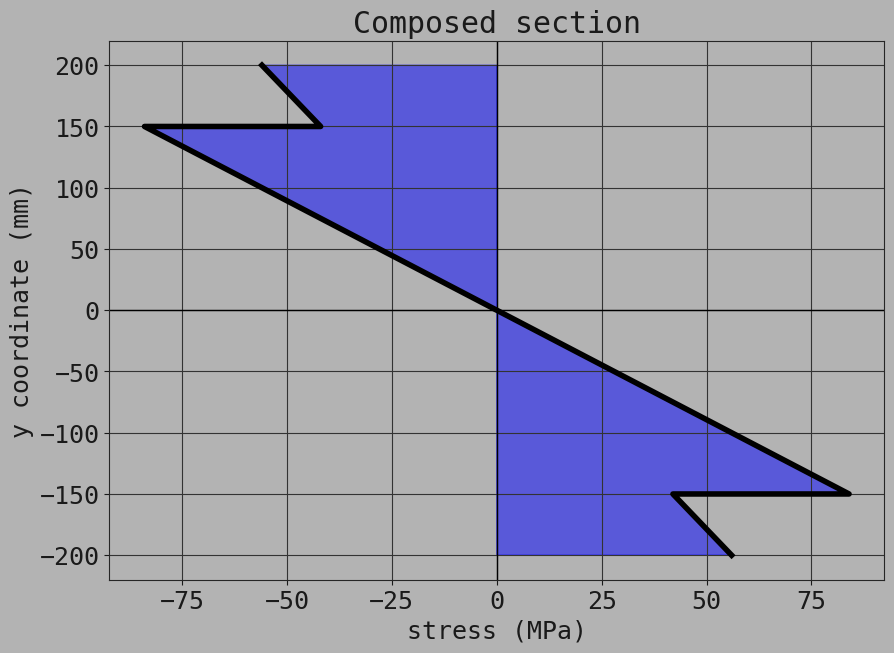

In [7]:
import matplotlib.pyplot as plt

# Your existing data
xplo2 = [-aco.sxx_ymax*1e6, -aco.sxx_ymin*1e6, -aco.sxx*1e6, aco.sxx*1e6, aco.sxx_ymin*1e6, aco.sxx_ymax*1e6]
yplo2 = [lat.ymax, lat.ymin, lat.ymin, -lat.ymin, -lat.ymin, -lat.ymax]

# Create a list to specify the colors for each segment (compression and tension)
colors = ['r' if y < lat.ymin else 'b' for y in yplo2]

fig, ax = plt.subplots(figsize=(10,7))

# Use fill_between to fill the area between the curve and the x-axis with colors
plt.fill_betweenx(yplo2, xplo2, color=colors, alpha=0.5)

# Plot the curve
plt.plot(xplo2, yplo2, '-k', linewidth=4)

plt.xlabel('stress (MPa)')
plt.ylabel('y coordinate (mm)')
plt.title('Composed section')
ax.axhline(y=0, color='k', linewidth=1)
ax.axvline(x=0, color='k', linewidth=1)
ax.grid()

# Show the plot
plt.show()


#### b) Sabendo que o espaçamento entre parafusos é de 300 mm, determine o maior valor da força de corte que os parafusos suportam.

Do formulário das tensões tangenciais em vigas com carregamentos transversais tem-se:

\begin{equation*}
q = \frac{V Q}{I_z}
\quad\wedge\quad
q = (m\cdot N)F
\quad\therefore\quad
F_\mathrm{max} = \frac{V_\mathrm{max} Q}{I_z m N}= \frac{V_\mathrm{max} Q h}{I_z m }
\end{equation*}

onde,

- $V_\mathrm{max}$ : corresponde à secção onde o esforço tranverso é máximo, resultante da análise dos diagramas de esforços (dado no enunciado).
- $Q$ : 1º momento de área da secção em corte (correspondente à zona isolada de latão).
- $m$: número de filas de parafusos: $m = 2$.
- $N$: número de parafusos por unidade de metro de comprimento
- $I_z$ : 2º momento de área ou momento de inércia de toda a secção transversal homogeneizada.

- Momento de área de primeira ordem (região da secção do latão na zona superior):

\begin{equation*}
Q = A_1 \overline{y}_1
\end{equation*}

In [27]:
y_1 = HEB300.d/2 + lat.t/2
Q = lat.A2a*y_1
Q_m = Q*1e-9
print(f'y = {y_1:.3f} [mm] | A = {lat.A2a:.3f} [mm] | Q = {Q:.3e} [mm³] = {Q_m:.3e} [m³]')

y = 175.000 [mm] | A = 7500.000 [mm] | Q = 1.312e+06 [mm³] = 1.313e-03 [m³]


A ligação aparafusada é realizada pela fixação de $N$ parafusos, em duas filas, em cada tábua superior e inferior.

Quantos parafusos ($N$) por metro de comprimento (1 m) estão presentes nesta ligação, sabendo que estes distam entre si de 300 mm?

\begin{equation*}
N = \frac{1000}{300} \left[\frac{\mathrm{unid. pregos}}{\mathrm{m}}\right]
\end{equation*}

In [9]:
m = d.paraffilas
print(f'filas de ligação aparafusada = {m:.1f} ')
N = 1e3/d.parafdist
print(f'n.º de parafusos por unidade (metro) de comprimento = {N:.1f} ')

filas de ligação aparafusada = 2.0 
n.º de parafusos por unidade (metro) de comprimento = 3.3 


In [10]:

print(f'V.max = {d.Vmax:.1f} [N]')
q = d.Vmax*Q_m/Iz_m
print(f'q.max = {d.Vmax:.3e} * {Q_m:.3e} \ {Iz_m:.3e} = {q:.3e} [N/m] = {q*1e-3:.1f} [kN/m]')
Fmax = q/m/int(N)
print(f'F..max = {q:.3e} \ {m} \ {int(N)} = {Fmax:.3e} [N] = {Fmax*1e-3:.1f} [kN]')
Fmax2 = q/m*d.parafdist*1e-3
print(f'F..max (espacamento) = {q:.3e} \ {m} \ d.parafdist = {Fmax2:.3e} [N] = {Fmax2*1e-3:.1f} [kN]')

V.max = 400000.0 [N]
q.max = 4.000e+05 * 1.313e-03 \ 7.145e-04 = 7.348e+05 [N/m] = 734.8 [kN/m]
F..max = 7.348e+05 \ 2 \ 3 = 1.225e+05 [N] = 122.5 [kN]
F..max (espacamento) = 7.348e+05 \ 2 \ d.parafdist = 1.102e+05 [N] = 110.2 [kN]


#### c) Calcule a tensão tangencial máxima que ocorre no perfil HEB300.

A tensão tangencial máxima ocorre no centro do perfil

\begin{equation*}
\tau_\mathrm{max} = \frac{q}{t_w} \frac{[N/m]}{[m]} = \frac{V_\mathrm{max} Q_\mathrm{max}}{I_zt_w}
\end{equation*}

É necessário como cálculo intermédio determinar $Q_\mathrm{max}$ para metade da secção em relação ao eixo neutro.

\begin{equation*}
Q_\mathrm{max} = (A_1\,\overline{y}_1)_\mathrm{latao2aco}
+ (A_2\,\overline{y}_2)_\mathrm{aco-banzo}
+ (A_3\,\overline{y}_3)_\mathrm{aco-alma}
\end{equation*}

com,

\begin{equation*}
(A_1\,\overline{y}_1)_\mathrm{latao2aco} = (n b) t \cdot (d/2+t/2)
\end{equation*}

\begin{equation*}
(A_2\,\overline{y}_2)_\mathrm{aco-banzo} = (b_f t_f) \cdot [d/2-t_f/2]
\end{equation*}

\begin{equation*}
(A_3\,\overline{y}_3)_\mathrm{aco-alma} = [(d/2-t_f)t_w ] \cdot [(d/2-t_f)/2]
\end{equation*}

In [28]:
# latao2aco:
R1_A = lat.A2a
R1_ycent = (HEB300.d/2 + lat.t/2)
Qlat2aco = R1_A * R1_ycent
print(f'area-lat2aco :: A = {R1_A} [mm^2] | y = {R1_ycent} [mm] | Q = {Qlat2aco} [mm^3]')
# HEB300-banzo
R2_A = (HEB300.bf*HEB300.tf)
R2_ycent = (HEB300.d/2 - HEB300.tf/2)
Qacobanzo =  R2_A * R2_ycent
print(f'area-HEB300-banzo :: A = {R2_A} [mm^2] | y = {R2_ycent} [mm] | Q = {Qacobanzo} [mm^3]')
# HEB300-alma
R3_A = ((HEB300.d/2-HEB300.tf)*HEB300.tw) 
R3_ycent = ((HEB300.d/2-HEB300.tf)/2)
Qacoalma = R3_A * R3_ycent
print(f'area-HEB300-alma :: A = {R3_A} [mm^2] | y = {R3_ycent} [mm] | Q = {Qacoalma} [mm^3]')

Qmax = Qlat2aco + Qacobanzo + Qacoalma
print(f'Qmax = {Qmax} [mm^3]')

taumax = d.Vmax*Qmax/Iz/HEB300.tw
print(f'taumax = {taumax:.2f} [MPa]')

area-lat2aco :: A = 7500.0 [mm^2] | y = 175.0 [mm] | Q = 1312500.0 [mm^3]
area-HEB300-banzo :: A = 5700.0 [mm^2] | y = 140.5 [mm] | Q = 800850.0 [mm^3]
area-HEB300-alma :: A = 1441.0 [mm^2] | y = 65.5 [mm] | Q = 94385.5 [mm^3]
Qmax = 2207735.5 [mm^3]
taumax = 112.36 [MPa]


---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>